Midterm 
- import packages 
- parse with pandas 
- create data frames 
- import images generator from tf 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import os
from tensorflow.keras import layers, regularizers
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight



In [2]:
#Define paths
base_path = "/Users/christy/Library/Mobile Documents/com~apple~CloudDocs/QMUL/ML&DL/Semester 2 (Deep Learning)/Midterm/hirise-map-proj-v3"
labels_file = os.path.join(base_path, "labels-map-proj-v3.txt")
images_folder = os.path.join(base_path, "map-proj-v3")

In [3]:
#load labels 

image_classes = np.loadtxt(labels_file, dtype=str, delimiter=" ")
df = pd.DataFrame(image_classes, columns=['filename','class'])
df['class'] = df['class'].astype(int)

print(df.head())

                            filename  class
0       ESP_011623_2100_RED-0069.jpg      0
1   ESP_011623_2100_RED-0069-r90.jpg      0
2  ESP_011623_2100_RED-0069-r180.jpg      0
3  ESP_011623_2100_RED-0069-r270.jpg      0
4    ESP_011623_2100_RED-0069-fh.jpg      0


## Need to chekc for NAN values and file paths 
### double check order for checking 
- open labels files 
- check all lables are valid 
- use valid labels to map to images 
- ensure all file paths to images are valid 

In [4]:
#check for NAN in text file 

df = df.dropna()
df['class'] = df['class'].astype(int)   

print(f"Total rows before image check: {len(df)}")

#check for missing images
def check_image_exists(filename):
    file_path = os.path.join(images_folder, filename)
    if os.path.isfile(file_path) and os.path.getsize(file_path) > 0:
        return True
    return False

df['is_valid_image'] = df['filename'].apply(check_image_exists)
df = df[df['is_valid_image']]
df = df.drop(columns=['is_valid_image'])
print(f"Total rows after image check: {len(df)}")


Total rows before image check: 73031
Total rows after image check: 73031


In [5]:
#load raw images

def load_raw_image(filename, label):
    """Read image file, decode"""
    img_path = tf.strings.join([images_folder, filename], separator="/")
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)  # ensure RGB
    return img, label

#process images, resize and normalize
"""resize and normalize images"""
def processed_image(img, label):
    img = tf.image.resize(img, [128, 128])
    img = img / 255.0
    return img, label

## Keep working on shuffling photos and plotting
### Need one photo from each class 

In [6]:
# shuffle the dataframe first
df = shuffle(df, random_state=22)  


#Then create dataset
filenames = df['filename'].values
labels = df['class'].values

# 1. Base slice dataset (just filenames + labels)
dataset = tf.data.Dataset.from_tensor_slices((filenames, labels))

# 2. Decode to raw images — capture this as your "before" snapshot
raw_ds = dataset.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)

# 3. Apply processing on top of raw — no second file read
processed_ds = raw_ds.map(processed_image, num_parallel_calls=tf.data.AUTOTUNE)

# 4. Only processed_ds goes into the training pipeline
train_ds = processed_ds.cache().shuffle(1000).batch(128).prefetch(tf.data.AUTOTUNE)


In [7]:
for images_batch, labels_batch in train_ds.take(1):
    print("Images shape:", images_batch.shape)
    print("Labels shape:", labels_batch.shape)
    print("Image dtype:", images_batch.dtype)
    print("Label dtype:", labels_batch.dtype)
    print("Pixel min/max:", images_batch.numpy().min(), images_batch.numpy().max())

Images shape: (128, 128, 128, 3)
Labels shape: (128,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int64'>
Pixel min/max: 0.0 1.0


2026-02-26 17:48:07.768771: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-02-26 17:48:07.778510: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


need to use batches
- its like feeding 30 pics instead of one at a time
- makes neural network faster (keeps GPU utilized)
- improved stability of training 

32 is the number of images
64, 64 is the image size 
3 color channels 

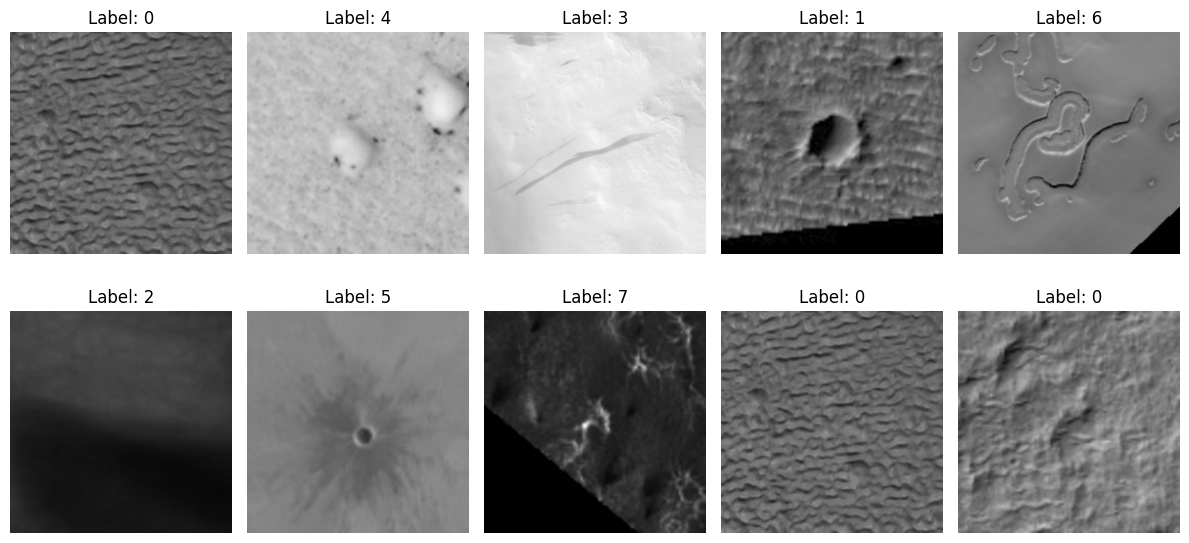

In [8]:
#plot data before preprocessing 

num_classes = 8
images_to_plot = []
labels_to_plot = []

#ensure one per class 
seen_class = set()

for image, label in raw_ds:
    label_val = int(label.numpy())

    if label_val not in seen_class:
        seen_class.add(label_val)
        images_to_plot.append(image.numpy())
        labels_to_plot.append(label_val)

    if len(seen_class) == num_classes:
        break

for image, label in raw_ds:
    if len (images_to_plot) >= 10:
        break
    images_to_plot.append(image.numpy())
    labels_to_plot.append(int(label.numpy()))

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images_to_plot[i].astype('uint8'))  # raw needs uint8 for display
    plt.title(f"Label: {labels_to_plot[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

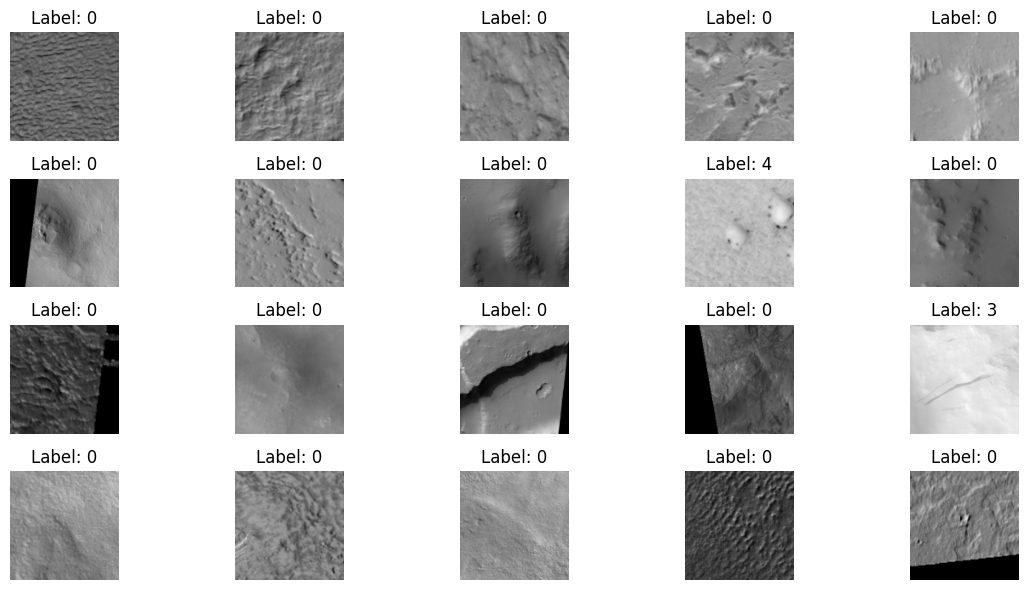

2026-02-26 17:48:08.453580: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
#post processing images

for images, labels in processed_ds.batch(20).take(1): 
    plt.figure(figsize=(12, 6))
    
    for i in range(20):
        plt.subplot(4, 5, i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

In [10]:
# Split the dataframe
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

print(train_df.shape)
print(test_df.shape)

def make_dataset(df, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((df['filename'].values, df['class'].values))
    dataset = dataset.map(load_raw_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(processed_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1000)  # only shuffle training data
    dataset = dataset.batch(128).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, training=True)
test_ds = make_dataset(test_df, training=False)

(51121, 2)
(21910, 2)


In [11]:
class_counts = df['class'].value_counts().sort_index()

print('Number of images per class:')
print(class_counts)

class_percentages =  df['class'].value_counts(normalize=True).sort_index() * 100
print('\nPercentage of images per class:')
print(class_percentages)

Number of images per class:
class
0    61054
1     4900
2     1141
3     2331
4     1750
5      231
6     1148
7      476
Name: count, dtype: int64

Percentage of images per class:
class
0    83.600115
1     6.709480
2     1.562350
3     3.191795
4     2.396243
5     0.316304
6     1.571935
7     0.651778
Name: proportion, dtype: float64


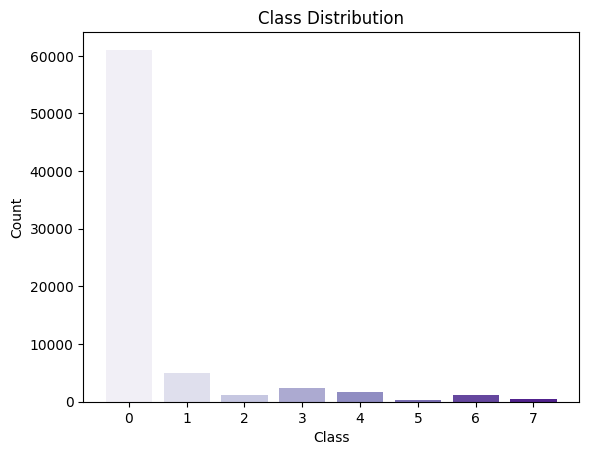

In [12]:
plt.bar(class_counts.index, class_counts.values, color=sns.color_palette("Purples", len(class_counts)))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.gca().set_xticks(range(len(class_counts)))
plt.gca().set_xticklabels(class_counts.index)
plt.show()

In [13]:
#Class imbalance 1 
# class weights to handle imbalance
class_counts = df['class'].value_counts().to_dict()
unique_classes = df['class'].unique()

weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=df['class'])

class_weights_dict = dict(enumerate(weights))
print(class_weights_dict)
for class_id, weight in class_weights_dict.items():
    print(f"Class {class_id}: Weight {weight:.4f}") 

{0: np.float64(0.14952132538408622), 1: np.float64(5.2165), 2: np.float64(3.9162912912912913), 3: np.float64(1.8630357142857144), 4: np.float64(7.951981707317073), 5: np.float64(8.000766871165645), 6: np.float64(39.51893939393939), 7: np.float64(19.178308823529413)}
Class 0: Weight 0.1495
Class 1: Weight 5.2165
Class 2: Weight 3.9163
Class 3: Weight 1.8630
Class 4: Weight 7.9520
Class 5: Weight 8.0008
Class 6: Weight 39.5189
Class 7: Weight 19.1783


In [14]:
#Smoothed balances 1 
smoothed_weights = np.sqrt(weights)
smoothed_weights_dict = dict(enumerate(smoothed_weights))
print("\nSmoothed Class Weights:")
for class_id, weight in smoothed_weights_dict.items():
    print(f"Class {class_id}: Smoothed Weight {weight:.4f}")


Smoothed Class Weights:
Class 0: Smoothed Weight 0.3867
Class 1: Smoothed Weight 2.2840
Class 2: Smoothed Weight 1.9790
Class 3: Smoothed Weight 1.3649
Class 4: Smoothed Weight 2.8199
Class 5: Smoothed Weight 2.8286
Class 6: Smoothed Weight 6.2864
Class 7: Smoothed Weight 4.3793


In [15]:
# model 1
# Remove ValidationSplit and BatchSize — handled by your datasets
Nepochs      = 20
DropoutValue = 0.5
NUM_CLASSES  = len(df['class'].unique())  # automatically counts your Mars classes

#define L2 regularization factor
l2_reg = 0.001

model = tf.keras.models.Sequential([
    # CNN layers to learn spatial features from images
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # Flatten and classify
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.keras.layers.LeakyReLU(alpha=0.1), kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.Dropout(DropoutValue),

    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

print("--------------------------------------------------------------------------------------------------------------")
print("\033[92mWill train a CNN on Martian Surface data\033[0m")
print("--------------------------------------------------------------------------------------------------------------\n\n")
print("Input data: Martian Surface Images (128x128 RGB)")
print("CNN + 2 layer MLP")
print("Dropout values       = ", DropoutValue)
print("Leaky relu parameter =  0.1")
print("Nepochs              = ", Nepochs, "\n")
print("N(train)             = ", len(train_df))
print("N(test)              = ", len(test_df))

# from_logits=False because softmax is already in the final layer
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=loss_fn,
    metrics=['accuracy']
)

# train_ds and test_ds replace x_train, y_train and validation_split
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=Nepochs,
    class_weight=smoothed_weights_dict 
)

--------------------------------------------------------------------------------------------------------------
Will train a CNN on Martian Surface data
--------------------------------------------------------------------------------------------------------------


Input data: Martian Surface Images (128x128 RGB)
CNN + 2 layer MLP
Dropout values       =  0.5
Leaky relu parameter =  0.1
Nepochs              =  20 

N(train)             =  51121
N(test)              =  21910
Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


400/400 ━━━━━━━━━━━━━━━━━━━━ 307s 763ms/step - accuracy: 0.7914 - loss: 1.3762 - val_accuracy: 0.8311 - val_loss: 1.0612
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 296s 738ms/step - accuracy: 0.7836 - loss: 1.1036 - val_accuracy: 0.8206 - val_loss: 0.9375
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 307s 767ms/step - accuracy: 0.7884 - loss: 0.9805 - val_accuracy: 0.7959 - val_loss: 0.9593
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 318s 795ms/step - accuracy: 0.7899 - loss: 0.9033 - val_accuracy: 0.8393 - val_loss: 0.7712
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 300s 749ms/step - accuracy: 0.7985 - loss: 0.8366 - val_accuracy: 0.7779 - val_loss: 0.8532
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 299s 746ms/step - accuracy: 0.8024 - loss: 0.7952 - val_accuracy: 0.7846 - val_loss: 0.8264
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 321s 802ms/step - accuracy: 0.8079 - loss: 0.7573 - val_accuracy: 0.7958 - val_loss: 0.8098
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 312s 779ms/step - accuracy: 0.8122 - loss: 0.73

## Second model tuning attempt 

In [16]:
##weights for model 2 
# max_weight = 3.0

# smoothed_weights_dict = {
#     k: min(v, max_weight)
#     for k, v in smoothed_weights_dict.items()
# }

# print("Capped class weights:", smoothed_weights_dict)

In [17]:
# #model 2
# import tensorflow as tf
# from tensorflow.keras import regularizers
# from tensorflow.keras.optimizers import Adam

# NUM_CLASSES = len(train_df['class'].unique())

# l2_reg = 1e-4
# DropoutValue = 0.3
# Nepochs = 25   # fixed number since no early stopping

# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal"),
#     tf.keras.layers.RandomRotation(0.1),
#     tf.keras.layers.RandomZoom(0.1),
# ])

# model = tf.keras.models.Sequential([

#     data_augmentation,

#     tf.keras.layers.Conv2D(32, 3, padding='same',
#                            kernel_regularizer=regularizers.l2(l2_reg)),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Activation('relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(64, 3, padding='same',
#                            kernel_regularizer=regularizers.l2(l2_reg)),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Activation('relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.Conv2D(128, 3, padding='same',
#                            kernel_regularizer=regularizers.l2(l2_reg)),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Activation('relu'),
#     tf.keras.layers.MaxPooling2D(),

#     tf.keras.layers.GlobalAveragePooling2D(),

#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dropout(DropoutValue),

#     tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
# ])

# model.compile(
#     optimizer=Adam(learning_rate=3e-4),
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#     metrics=['accuracy']
# )

# model.summary()

In [18]:
##fitting model 2
# history = model.fit(
#     train_ds,
#     validation_data=test_ds,
#     epochs=Nepochs,
#     class_weight=smoothed_weights_dict 
# )

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Nepochs: 20


Text(0.5, 1.0, 'Training and Validation Accuracy')

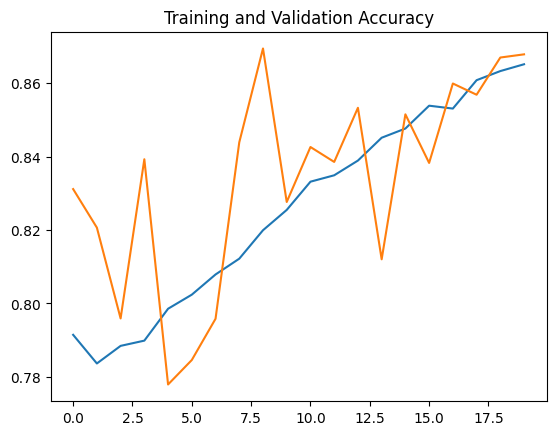

In [19]:
#plot training accuracy

print(history.history.keys())  # to check available metrics
print("Nepochs:", Nepochs)


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')

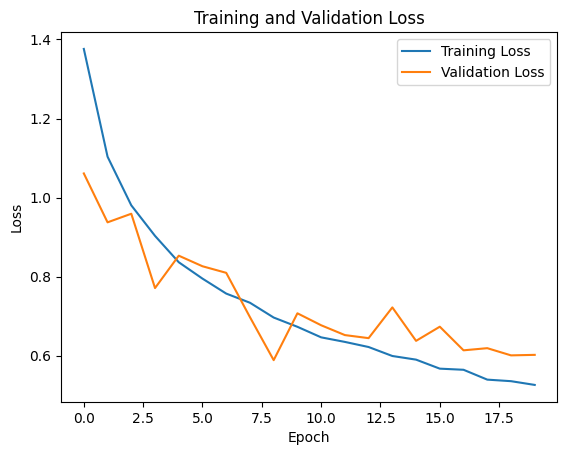

Performance on test set
172/172 - 40s - 235ms/step - accuracy: 0.8678 - loss: 0.6023
Test Loss: 0.602, Test Accuracy: 0.868


In [20]:
#plot loss history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("Performance on test set")
loss, acc, = model.evaluate(test_ds, verbose=2)
print(f"Test Loss: {loss:5.3f}, Test Accuracy: {acc:5.3f}")

In [21]:
#predictions for confusion matrix

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step


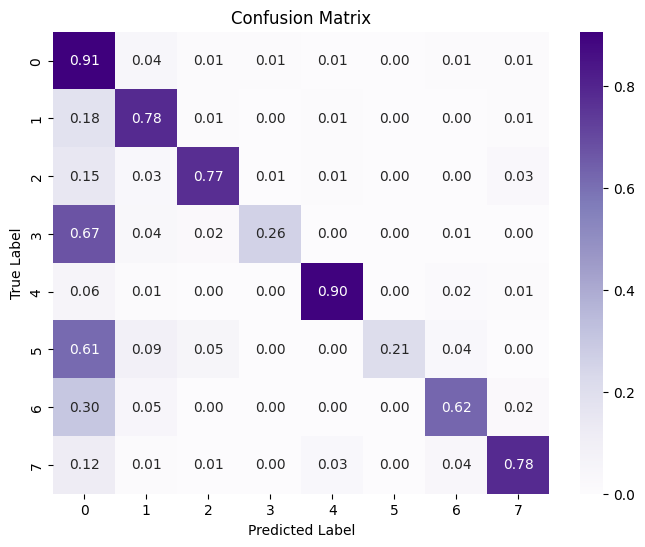

In [22]:
#plot confusion matrix 

if len(y_true) > 1 and y_true.shape[0] == y_pred_classes.shape[0]:
    # normalize must be one of {'true', 'pred', 'all'} or None (string values)
    cm = confusion_matrix(y_true, y_pred_classes, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    print("Error: Mismatch in number of samples between y_true and y_pred_classes.")

In [23]:
class_names = [f"Class {i}" for i in range(NUM_CLASSES)]

report = classification_report(y_true, y_pred_classes, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

     Class 0       0.94      0.91      0.93     18375
     Class 1       0.57      0.78      0.66      1439
     Class 2       0.48      0.77      0.59       343
     Class 3       0.55      0.26      0.35       704
     Class 4       0.77      0.90      0.83       501
     Class 5       0.63      0.21      0.32        57
     Class 6       0.45      0.62      0.52       344
     Class 7       0.33      0.78      0.46       147

    accuracy                           0.87     21910
   macro avg       0.59      0.65      0.58     21910
weighted avg       0.88      0.87      0.87     21910



Precision vs Recall 
- precision - accuracy of positive predictions 
    - TP / TP + FP 
- recall - how many images did the model find 
    - TP / TP + FN 
- F1 - harmonic mean of both balanceing false positives and negatives 
    - (2 * (P * R / P + R))